# Inference Multi-variable Diffusion-Convection-Reaction

# Checking out data attributes

In [2]:
import h5py

raw_data_path = '/Volumes/T7/PDEFoundry2/MVDCR/dedalus_v5.1_MCompn2D_hom_fNL0_nv2_cU1_k1e-03_0.01_seed0.hdf5'

with h5py.File(raw_data_path, 'r') as f:
    print(f.keys())
    print()

    print('ARGS:')
    print(f['args'].keys())
    for keys in f['args'].keys():
        value = f['args'][keys][()]
        print(f'{keys}: {value}')
    print()

    print('COEF:')
    print(f['coef'].keys())

    # print(f['coef']['f0'])
    # print(f['coef']['f1'])
    # print(f['coef']['f2'])
    for k1 in f['coef'].keys():
        print(k1)
        for k2 in f['coef'][k1].keys():
            node = f['coef'][k1][k2]
            if isinstance(node, h5py.Group):
                print(" ", k2)
                for k3 in node.keys():
                    obj = node[k3]
                    print("   ", k3, obj.shape)
            else:
                print(" ", k2, node.shape)
    print()

    print('COORD:')
    print(f['coord'].keys())
    for keys in f['coord'].keys():
        value = f['coord'][keys]
        print(f'{keys}: {value}')
    print()

    print('PDE_INFO:')
    print(f['pde_info'].keys())
    for keys in f['pde_info'].keys():
        value = f['pde_info'][keys][()]
        print(f'{keys}: {value}')
    print()

    print('SOL:')
    print(f['sol'].keys())
    for keys in f['sol'].keys():
        value = f['sol'][keys]
        print(f'{keys}: {value}')

    # 1000 sims, 101 timesteps, 128x128
    # f0 has entries for deg2 and lin
    # f1/f2 has entries for lin, but no entries for deg2


<KeysViewHDF5 ['args', 'coef', 'coord', 'pde_info', 'sol']>

ARGS:
<KeysViewHDF5 ['coef_magnitude', 'flux_num_nonlin', 'inhom_diff_u', 'kappa_max', 'kappa_min', 'n_vars', 'np_seed', 'num_pde', 'num_sol_buffer', 'num_sol_per_npy', 'periodic', 'plot_results', 'print_coef_level', 'record_failed_samples', 'resume', 'terminate_on_save', 'u_bound']>
coef_magnitude: 1.0
flux_num_nonlin: 0
inhom_diff_u: False
kappa_max: 0.01
kappa_min: 0.001
n_vars: 2
np_seed: 0
num_pde: 1000
num_sol_buffer: 20
num_sol_per_npy: 0
periodic: [ True  True]
plot_results: False
print_coef_level: 0
record_failed_samples: False
resume: True
terminate_on_save: False
u_bound: 10

COEF:
<KeysViewHDF5 ['Lu', 'f0', 'f1', 'f2', 's', 'u_ic']>
Lu
  0
    diff_type (1000,)
    value (1000,)
  1
    diff_type (1000,)
    value (1000,)
f0
  deg2
    coo_i (1000, 4)
    coo_j (1000, 4)
    coo_k (1000, 4)
    coo_len (1000,)
    coo_vals (1000, 4)
  lin
    coo_i (1000, 4)
    coo_j (1000, 4)
    coo_len (1000,)
    coo_vals (10

# Load model

In [1]:
#LOAD MODEL
import numpy as np
import matplotlib.pyplot as plt
from mindspore import context
from src import load_config, get_model, PDENodesCollector, sample_grf
from src.inference import infer_plot_2d, x_fenc, y_fenc, interp_fenc

# basic setting
context.set_context(mode=context.GRAPH_MODE, device_target="CPU")
config = load_config("configs/inference/model-M.yaml")
model = get_model(config)

[WARNING] ME(22087:8286985856,MainProcess):2026-06-29-16:29:35.361.000 [mindspore/context.py:1334] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


# Load pde_type and generate DAG

2
After c_or_c2: [('uf0', 'uf'), ('uf1', 'uf'), ('coef2', 'coef'), ('mul3', 'mul', 'coef2', 'uf0'), ('coef4', 'coef'), ('mul5', 'mul', 'coef4', 'uf0'), ('mul6', 'mul', 'uf0', 'uf1'), ('coef7', 'coef'), ('mul8', 'mul', 'coef7', 'uf1'), ('ic9', 'ic', 'uf0'), ('dx10', 'dx', 'uf1'), ('dy11', 'dy', 'uf1'), ('cf12', 'cf'), ('coef13', 'coef')]
After c_or_c2: [('uf0', 'uf'), ('uf1', 'uf'), ('coef2', 'coef'), ('mul3', 'mul', 'coef2', 'uf0'), ('coef4', 'coef'), ('mul5', 'mul', 'coef4', 'uf0'), ('mul6', 'mul', 'uf0', 'uf1'), ('coef7', 'coef'), ('mul8', 'mul', 'coef7', 'uf1'), ('ic9', 'ic', 'uf0'), ('dx10', 'dx', 'uf1'), ('dy11', 'dy', 'uf1'), ('cf12', 'cf'), ('coef13', 'coef'), ('dx14', 'dx', 'uf0'), ('mul15', 'mul', 'dx14', 'coef13'), ('dx16', 'dx', 'mul15'), ('dy17', 'dy', 'uf0'), ('mul18', 'mul', 'dy17', 'coef13'), ('dy19', 'dy', 'mul18'), ('add20', 'add', 'dy19', 'dx16'), ('mul21', 'mul', 'add20', 'coef13'), ('neg22', 'neg', 'mul21'), ('dt23', 'dt', 'uf0'), ('add24', 'add', 'mul3', 'uf1', 'mu

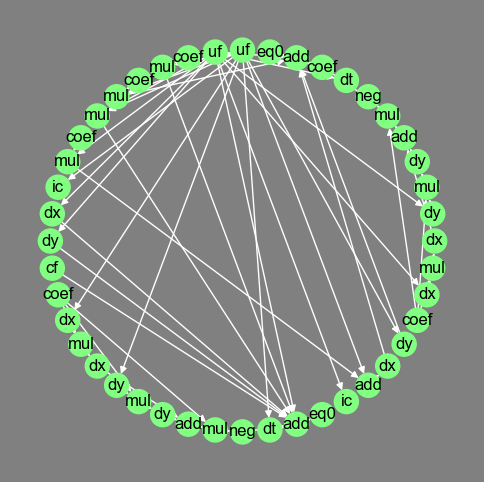

Total num of samples: 1


In [2]:
import h5py
from src.data.multi_pde.pde_types import get_pde_info_cls

raw_data_path = '/Volumes/T7/PDEFoundry2/MVDCR/dedalus_v5.1_MCompn2D_hom_fNL0_nv2_cU1_k1e-03_0.01_seed0.hdf5'

pde_type = get_pde_info_cls('mvdcr')
idx_test = [0]
# idx_test = list(range(0, 30))
pde_dags_list = []

with h5py.File(raw_data_path, 'r') as f:
    for idx in idx_test:
        pde = pde_type.pde_nodes(f, idx, keep_all_coef=False)
        pde_dag = pde.gen_dag(config)
        pde_dag.plot(hide='aux')
        pde_dags_list.append(pde_dag)

print(f'Total num of samples: {len(pde_dags_list)}')

# Inference and plotting
Note that the first row is component u, and the second row is component v

[WARNING] SESSION(22087,0x1edf15e80,Python):2026-06-29-16:30:44.557.863 [mindspore/ccsrc/backend/common/expander/fallback/expander_fallback.cc:266] IbTryExpandCNode] After expanding cnode Default/SumExt-op0, the new abstract of Expand/_SumExt/ReduceSum-op0 does not match original cnode's abstract. new: AbstractTensor(shape: (1, 216, 768), element: AbstractScalar(Type: Float32, Value: ValueAny, Shape: NoShape), value_ptr: 0x600000501b48, value: ValueAny), old: AbstractRefTensor(key: 0x60002d9c7c1839, ref_value: AbstractRefTensor(shape: (1, 216, 768), element: AbstractScalar(Type: Float32, Value: ValueAny, Shape: NoShape), value_ptr: 0x600000501b48, value: ValueAny), value: ValueAny, is_inplace)
[WARNING] SESSION(22087,0x1edf15e80,Python):2026-06-29-16:30:44.557.914 [mindspore/ccsrc/backend/common/expander/fallback/expander_fallback.cc:274] IbTryExpandCNode] Restore new abstract to AbstractRefTensor new:AbstractRefTensor(key: 0x60002d9c7c1839, ref_value: AbstractRefTensor(shape: (1, 216,

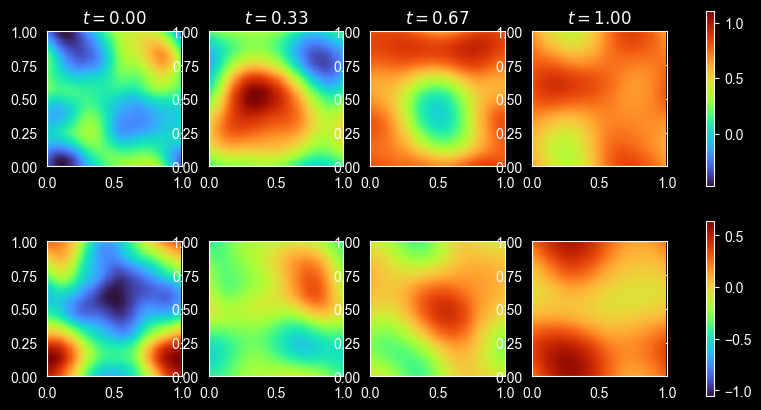

Simulation: 0
(4, 128, 128, 2)


In [3]:
#Set grid space to 128x128, and set to predict 4 time points [0,0.33,0.67,1.00].
#Number of time points predicted can be adjusted.
x_plot, y_plot = np.meshgrid(np.linspace(0, 1, 129)[:-1], np.linspace(0, 1, 129)[:-1], indexing="ij")
snap_t=np.linspace(0, 1, 4)

for i, dag_idx in enumerate(pde_dags_list):
    pred = infer_plot_2d(model, dag_idx, x_plot, y_plot, snap_t=snap_t)
    print('Simulation:', i)
    print(pred.shape)

# Custom plotting code
This block contains code used to plot the ground truth, pred, and absolute error for a single component in a single plot.

Only component u for MVDCR is plotted below.

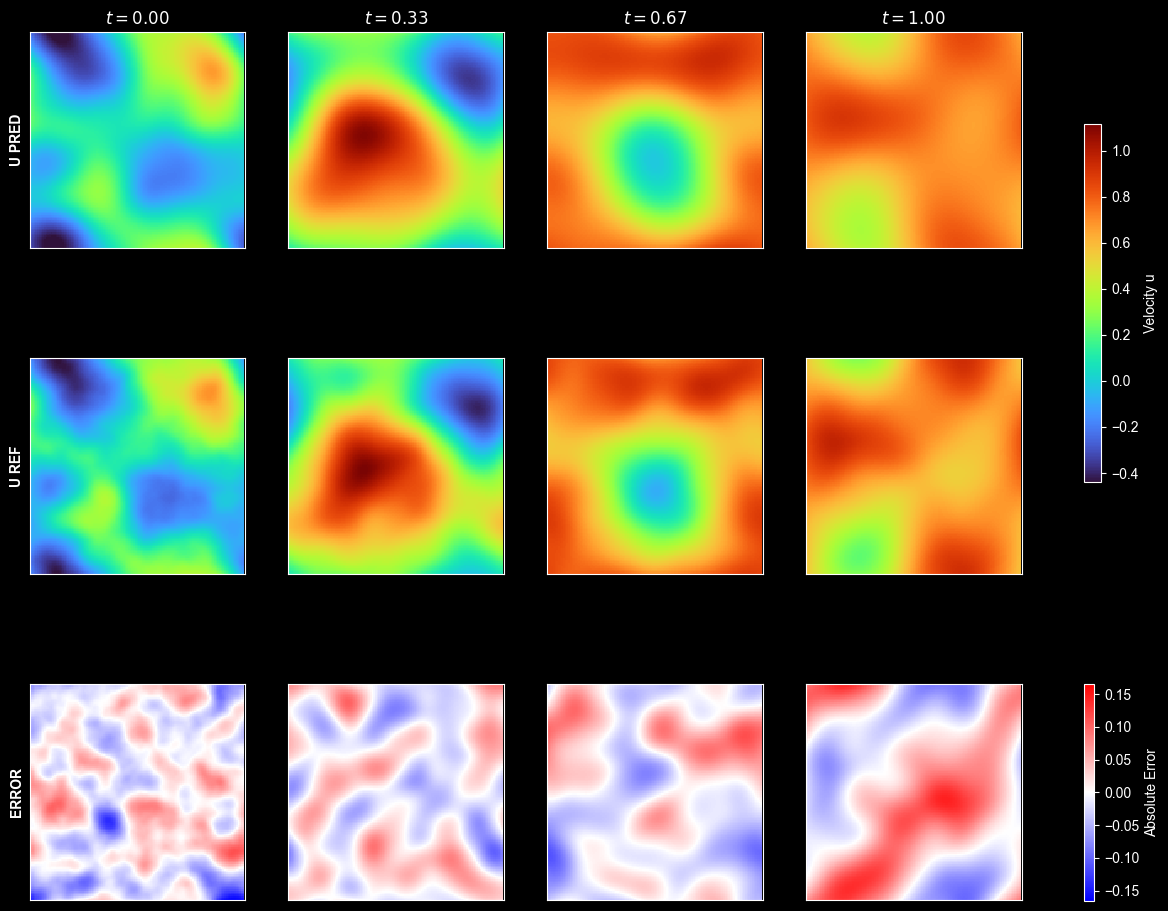

In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(raw_data_path, "r") as f:
    x_raw = f['coord/x'][:].flatten()
    y_raw = f['coord/y'][:].flatten()
    t_raw = f['coord/t'][:].flatten()
    x_ext, y_ext = np.meshgrid(x_raw, y_raw, indexing="ij")

    u_raw_full = f['sol/u0'][0]

t_times = [0, 0.33, 0.67, 1.00]
t_int = [int(t * (len(t_raw) - 1)) for t in t_times]
n_t = len(t_int)

pred_snap = pred[..., 0]   # (4, 128, 128)
ref_snap = u_raw_full[t_int] # (4, 128, 128)

vmin, vmax = ref_snap.min(), ref_snap.max()
vmax_err = np.abs(pred_snap - ref_snap).max()

size_unit = 4
fig, axes = plt.subplots(3, n_t, squeeze=False,
                         figsize=(n_t * size_unit, 3 * size_unit))

for col in range(n_t):
    t_val = t_raw[t_int[col]]

    # Row 0: Pred
    im_p = axes[0, col].pcolormesh(x_ext, y_ext, pred_snap[col],
                                   cmap='turbo', vmin=vmin, vmax=vmax)

    axes[0, col].set_title(f"$t={t_val:.2f}$")

    # Row 1: Ref
    im_r = axes[1, col].pcolormesh(x_ext, y_ext, ref_snap[col],
                                   cmap='turbo', vmin=vmin, vmax=vmax)

    # Row 2: Error
    err = pred_snap[col] - ref_snap[col]
    im_e = axes[2, col].pcolormesh(x_ext, y_ext, err,
                                   cmap='bwr', vmin=-vmax_err, vmax=vmax_err)

    for row in range(3):
        axes[row, col].set_xlim(0, 1)
        axes[row, col].set_ylim(0, 1)
        axes[row, col].set_aspect(1)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

#Colorbar for Pred and Ref
fig.colorbar(im_r, ax=axes[0:2, :], location='right', shrink=0.6, label='Velocity u')

# Colorbar for Error row
fig.colorbar(im_e, ax=axes[2, :], location='right', shrink=0.8, label='Absolute Error')

# Labels
axes[0, 0].set_ylabel("U PRED", fontweight='bold')
axes[1, 0].set_ylabel("U REF", fontweight='bold')
axes[2, 0].set_ylabel("ERROR", fontweight='bold')

plt.show()

# L2 error calculation
I use calculate_l2_error that is provided in PDEFormer's own codebase.

Unlike the prediction above, where only 4 timesteps are predicted, we now predict all timesteps of our data, without plotting.

Only 1 simulation is used here, but this code block can also be used for multiple simulations

In [6]:
#COMPUTING L2 ERROR for 1 simulation, 101 timesteps each
from src.inference import inference_pde
from src.core.metric import calculate_l2_error
from mindspore import Tensor
import h5py

raw_data_path = '/Volumes/T7/PDEFoundry2/MVDCR/dedalus_v5.1_MCompn2D_hom_fNL0_nv2_cU1_k1e-03_0.01_seed0.hdf5'
idx_test = [0]

errors_global_list = []
errors_u0_list = []
errors_u1_list = []

with h5py.File(raw_data_path, 'r') as f:
    t_all = f['coord/t'][:].flatten()
    x_raw = f['coord/x'][:].flatten()
    y_raw = f['coord/y'][:].flatten()
    x_grid, y_grid = np.meshgrid(x_raw, y_raw, indexing="ij")

    num_t = len(t_all) # 101

    for sim_idx, dag in enumerate(pde_dags_list):
        print('Simulation:', sim_idx)

        #Reference/Ground truth
        ref_all = np.stack([
            f['sol/u0'][sim_idx][:],
            f['sol/u1'][sim_idx][:]
        ], axis=-1)

        preds_list = []

        for i in range(num_t):
            # Shape (1, 128, 128, 4), format (t, x, y, z), as per inference_pde code input
            t_step = t_all[i]
            coord_step = np.stack(np.broadcast_arrays(
                t_step, x_grid, y_grid, 0
            ), axis=-1)[None, ...]

            # Inference without plots
            pred_step = inference_pde(model, dag, coord_step)
            preds_list.append(pred_step)

        pred_all = np.concatenate(preds_list, axis=0)
        print(pred_all.shape)

        # Error derivation
        # Global Error
        rel_l2_global = calculate_l2_error(Tensor(pred_all), Tensor(ref_all))

        rel_l2_u0 = calculate_l2_error(Tensor(pred_all[..., 0]), Tensor(ref_all[..., 0]))
        rel_l2_u1 = calculate_l2_error(Tensor(pred_all[..., 1]), Tensor(ref_all[..., 1]))

        print(f"Mean Rel L2 (Global): {np.mean(rel_l2_global):.6f}")
        print(f"Mean Rel L2 (u0):     {np.mean(rel_l2_u0):.6f}")
        print(f"Mean Rel L2 (u1):     {np.mean(rel_l2_u1):.6f}")

        errors_global_list.append(rel_l2_global)
        errors_u0_list.append(rel_l2_u0)
        errors_u1_list.append(rel_l2_u1)

errors_global = np.array(errors_global_list)
errors_u0 = np.array(errors_u0_list)
errors_u1 = np.array(errors_u1_list)

print('\n--- Final Results ---')
print(f"Overall Mean Rel L2 (Global): {np.mean(errors_global):.6f}")
print(f"Overall Mean Rel L2 (u0):     {np.mean(errors_u0):.6f}")
print(f"Overall Mean Rel L2 (u1):     {np.mean(errors_u1):.6f}")

Simulation: 0


[WARNING] ANALYZER(22087,0x1edf15e80,Python):2026-06-29-16:45:35.545.651 [mindspore/ccsrc/frontend/jit/ps/static_analysis/auto_monad.cc:1608] ClearIsolatedNodes] Some side effect nodes were eliminated by mistake. The node is:@8048_src_cell_pdeformer_pdeformer_PDEEncoder_construct_425:_{[0]: ValueNode<FuncGraph> 10609__tuple_getitem_by_number_426, [1]: ValueNode<ValueTuple> (1, 6, 16384, 5), [2]: ValueNode<Int64Imm> 3}
[WARNING] ANALYZER(22087,0x1edf15e80,Python):2026-06-29-16:45:35.545.833 [mindspore/ccsrc/frontend/jit/ps/static_analysis/auto_monad.cc:1608] ClearIsolatedNodes] Some side effect nodes were eliminated by mistake. The node is:@10742_src_cell_pdeformer_function_encoder_Conv2dFuncEncoderV3_construct_427:_{[0]: ValueNode<FuncGraph> 10902__tuple_getitem_by_number_428, [1]: ValueNode<ValueTuple> (6, 16384, 5), [2]: ValueNode<Int64Imm> 1}
[WARNING] ANALYZER(22087,0x1edf15e80,Python):2026-06-29-16:45:35.546.738 [mindspore/ccsrc/frontend/jit/ps/static_analysis/auto_monad.cc:1601] 

(101, 128, 128, 2)
Mean Rel L2 (Global): 0.084174
Mean Rel L2 (u0):     0.080961
Mean Rel L2 (u1):     0.142864

--- Final Results ---
Overall Mean Rel L2 (Global): 0.084174
Overall Mean Rel L2 (u0):     0.080961
Overall Mean Rel L2 (u1):     0.142864
